# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix
import joblib

# Functions

In [2]:
def data_info(dataframe: pd.DataFrame, target_col: str = None):
  """Prints the main DataSet information: Shape, Missing Values, Duplicates, Target Variable Proportion, Numerical/Categorical Features.
  Requires a pd.DataFrame object."""
  if not isinstance(dataframe, pd.DataFrame):
    raise TypeError("dataframe must be a pd.DataFrame object.")
  else:
    pass
  print(f"Dataset Shape: {dataframe.shape[0]} rows, {dataframe.shape[1]} columns")
  print("\n=================\n")
  print(f"Number of Missing Values: {dataframe.isnull().sum()}")
  print("\n=================\n")
  print(f"Number of Duplicates: {dataframe.duplicated().sum()}")
  print("\n=================\n")
  if target_col is not None:
    counts = dataframe[target_col].value_counts()
    perms = dataframe[target_col].value_counts(normalize=True) * 100
    print(f"Target Variable: {target_col}")
    for val in counts.index:
      print(f"Class {val}: "
      f"{counts[val]} occurrences "
      f"({perms[val]:.4f}%)")
  else:
    pass
  print("\n=================\n")
  num_var = dataframe.select_dtypes(include=['number']).columns.tolist()
  cat_var = dataframe.select_dtypes(include=['object', 'category', 'boolean']).columns.tolist()
  print(f"Numerical Features Count: {len(num_var)}")
  print(f"Categorical Features Count: {len(cat_var)}")
  if cat_var:
    print(f"Categorical Features list: {cat_var}")

  print("\n=================\n")
  return None

In [3]:
def clean_data(dataframe: pd.DataFrame, missing_strategy='drop', fill_value=None, remove_duplicates=True):
  if not isinstance(dataframe, pd.DataFrame):
    raise TypeError("dataframe must be a pd.DataFrame object.")
  else:
    pass

  df_clean = dataframe.copy()
  total_nan = df_clean.isnull().sum().sum()
  if total_nan > 0:
    print(f"Found {total_nan} Missing Values.")
    print("How would you like to handle them?")
    print("1. Drop rows with Missing Values (dropna).")
    print("2. Fill Missing Values with specific values (fillna).")
    print("3. Forward Fill/Bacward Fill (ffill/bfill)")
    print("4. Do nothing (NOT SUGGESTED).")

    if missing_strategy == 'drop':
      df_clean = df_clean.dropna()
      print("Missing values dropped.")

    elif missing_strategy == 'fill':
      df_clean = df_clean.fillna(fill_value)
      print(f"Missing values filled with "
      f"{fill_value}")

    elif missing_strategy == 'ffill':
      df_clean = df_clean.ffill()
      print("Forward fill applied.")

    elif missing_strategy == 'bfill':
      df_clean = df_clean.bfill()
      print("Backward fill applied.")

    else:
      print("Missing values left untouched.")
  else:
    pass

  total_duplicates = df_clean.duplicated().sum()
  if total_duplicates > 0:
    if remove_duplicates:
      df_clean = df_clean.drop_duplicates(keep='first')
      print("Duplicates removed.")
    else:
      print("Duplicates kept.")
  else:
    print("No duplicates found.")

  print("\n=================\n")
  print("Data cleaning process completed.")
  return df_clean

In [4]:
def split_data(dataframe: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42):
    """
    Splits the dataframe into Train and Test sets using Stratification.
    """
    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError("dataframe must be a pd.DataFrame object.")

    X_raw = dataframe.drop(columns=[target_col])
    y_raw = dataframe[target_col]
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y_raw, test_size=test_size, random_state=random_state, stratify=y_raw)

    print(f"Train set target ratio:\n{y_train.value_counts(normalize=True) * 100}")
    print(f"Test set target ratio:\n{y_test.value_counts(normalize=True) * 100}")
    print("---------------------------------------\n")

    return X_train_raw, X_test_raw, y_train, y_test

In [15]:
def preprocess_data(X_train: pd.DataFrame, X_test: pd.DataFrame):
    """
    Fits a ColumnTransformer (RobustScaler + OneHotEncoder) on X_train
    and transforms both X_train and X_test to avoid Data Leakage.
    """
    num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
    cat_cols = X_train.select_dtypes(include=['object', 'category', 'boolean']).columns.tolist()

    print(f"Numerical Features: {len(num_cols)}")
    print(f"Categorical Features: {len(cat_cols)}")

    preprocessor = ColumnTransformer(transformers=[
        ('num', RobustScaler(), num_cols),('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)],remainder='passthrough')

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)
    new_cols = preprocessor.get_feature_names_out()
    X_train_final = pd.DataFrame(X_train_transformed, columns=new_cols, index=X_train.index)
    X_test_final = pd.DataFrame(X_test_transformed, columns=new_cols, index=X_test.index)

    print("Preprocessing completed.")
    return X_train_final, X_test_final

In [6]:
def compare_models(X_train, X_test, y_train, y_test):
  """
    Trains and compares 4 configurations:
    1. RandomForest (Balanced weights)
    2. RandomForest (with SMOTE)
    3. Logistic Regression (Balanced weights)
    4. Logistic Regression (with SMOTE)
    """
  smote = SMOTE(random_state=10)
  X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

  models = {
      "RandomForest (Class Weight)": (RandomForestClassifier(class_weight='balanced', random_state=10, n_jobs=-1), X_train, y_train),
      "RandomForest (SMOTE)": (RandomForestClassifier(random_state=10, n_jobs=-1), X_train_smote, y_train_smote),
      "Logistic Regression (Class Weight)": (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=10), X_train, y_train),
      "Logistic Regression (SMOTE)": (LogisticRegression(max_iter=1000, random_state=10), X_train_smote, y_train_smote)
  }
  results=[]
  trained_models = {}
  for name, (model, X_tr, y_tr) in models.items():
    print(f"Training of {name}...")
    model.fit(X_tr, y_tr)
    trained_models[name] = model
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
      y_probs = model.predict_proba(X_test)[:, 1]
      auprc = average_precision_score(y_test, y_probs)
    else:
      auprc = None

    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    results.append({
            "Model/Configuration": name,
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1-Score": round(f1, 4),
            "AUPRC": round(auprc, 4) if auprc is not None else "N/A"})
  df_results = pd.DataFrame(results)

  print("\n================= MODELS RESULTS =================")
  print(df_results.to_string(index=False))
  print("=================================================================\n")

  best_model_name = (df_results.sort_values("AUPRC",ascending=False).iloc[0]["Model/Configuration"])

  return (df_results, trained_models, best_model_name)

In [26]:
def plot_best_model_matrix(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Legitimate (0)', 'Fraud (1)'],
                yticklabels=['Legitimate (0)', 'Fraud (1)'])

    plt.title('Confusion Matrix - RandomForest (SMOTE)', fontsize=14, pad=15)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print("\n--- ANALYSIS IN ABSOLUTE NUMBERS ---")
    print(f"Legitimate transactions correctly identified (True Negatives): {tn}")
    print(f"Customers Blocked by Mistake (False Positives): {fp}")
    print(f"Fraud cases that slipped through the cracks (false negatives): {fn}")
    print(f"Fraud successfully detected (True Positives): {tp}")
    print("----------------------------------\n")

    return cm

def plot_feature_importance(model,X_train):
    if not hasattr(model, "feature_importances_"):
      print("Feature importance "
            "not available.")
      return

    importance = pd.Series(model.feature_importances_, index=X_train.columns)

    importance = (importance.sort_values(ascending=False).head(15))
    plt.figure(figsize=(8, 6))
    importance.sort_values().plot(kind='barh')
    plt.title("Top 15 Feature Importances")
    plt.tight_layout()
    plt.show()

# Application

In [16]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)
csv_filename = "creditcard.csv"
full_csv_path = os.path.join(path, csv_filename)
df = pd.read_csv(full_csv_path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [17]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [18]:
data_info(df, target_col='Class')

Dataset Shape: 284807 rows, 31 columns


Number of Missing Values: Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


Number of Duplicates: 1081


Target Variable: Class
Class 0: 284315 occurrences (99.8273%)
Class 1: 492 occurrences (0.1727%)


Numerical Features Count: 31
Categorical Features Count: 0




In [19]:
df = clean_data(df, missing_strategy='drop', remove_duplicates=True)

Duplicates removed.


Data cleaning process completed.


In [20]:
X_train_raw, X_test_raw, y_train, y_test = split_data(df, target_col='Class')
X_train, X_test = preprocess_data(X_train_raw, X_test_raw)

Train set target ratio:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64
Test set target ratio:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64
---------------------------------------

Numerical Features: 30
Categorical Features: 0
Preprocessing completed.


In [21]:
(final_results, trained_models, best_model_name) = compare_models(X_train, X_test, y_train, y_test)
print(f"\nBest model: {best_model_name}")

Training of RandomForest (Class Weight)...
Training of RandomForest (SMOTE)...
Training of Logistic Regression (Class Weight)...
Training of Logistic Regression (SMOTE)...

================= MODELS RESULTS =================
               Model/Configuration  Precision  Recall  F1-Score  AUPRC
       RandomForest (Class Weight)     0.9855  0.7158    0.8293 0.8116
              RandomForest (SMOTE)     0.9231  0.7579    0.8324 0.8135
Logistic Regression (Class Weight)     0.0564  0.8737    0.1059 0.6718
       Logistic Regression (SMOTE)     0.0550  0.8737    0.1036 0.6728


Best model: RandomForest (SMOTE)


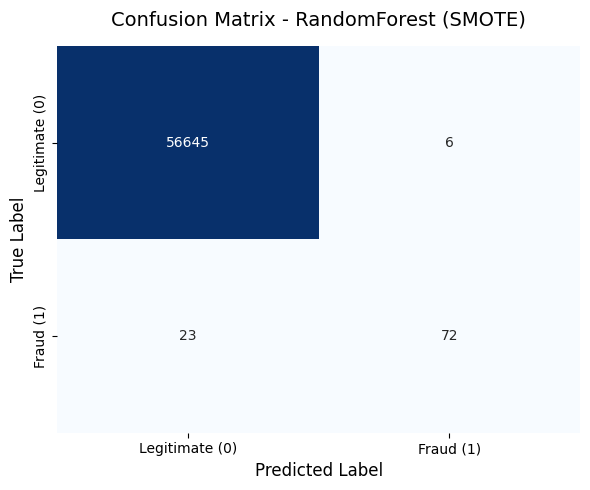


--- ANALYSIS IN ABSOLUTE NUMBERS ---
Legitimate transactions correctly identified (True Negatives): 56645
Customers Blocked by Mistake (False Positives): 6
Fraud cases that slipped through the cracks (false negatives): 23
Fraud successfully detected (True Positives): 72
----------------------------------



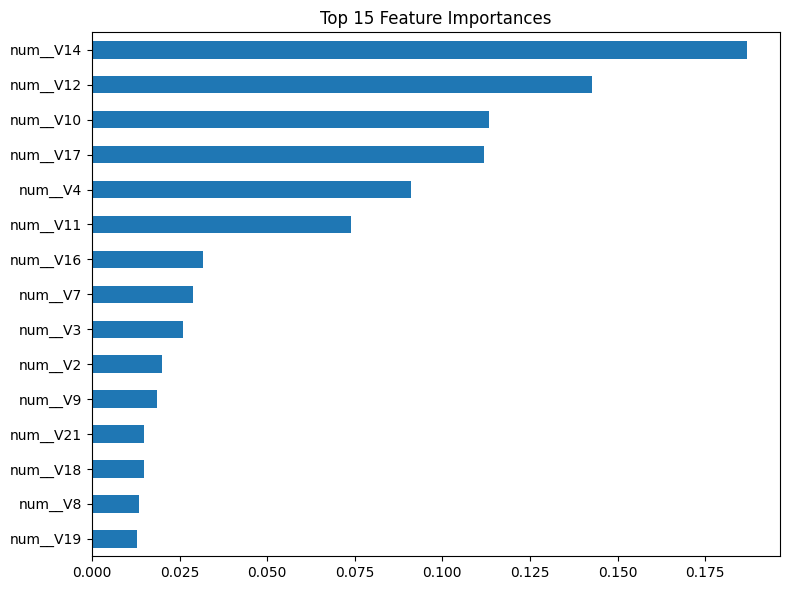

Model saved as 'fraud_detection_model.pkl'


In [27]:
rf_model = trained_models["RandomForest (SMOTE)"]
plot_best_model_matrix(rf_model, X_test, y_test)
plot_feature_importance(rf_model, X_train)
joblib.dump(rf_model, "fraud_detection_model.pkl")
print("Model saved as "
    "'fraud_detection_model.pkl'")